In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def flux_to_mag_nJy(flux):
    """ Convert flux from nano-Jansky to AB Magnitude

    1 Jy = 1e-23 erg/cm2/s/Hz
    Fnu = 3631 Jy = 3.631*1e-20 erg/cm2/s/Hz
    ABmag = 0-2.5*log10( Fnu )-48.6 = 0

    :param flux: flux in nano-Jansky
    :return: mag: as the AB Magnitude
    """

    mag = -2.5 * np.log10(flux*1e-9*1.0e-26) - 48.6
    return mag

In [63]:
tract = pd.read_parquet('../data/tract_2000_2999.parquet', engine='pyarrow')
tract

,ra,dec,nDiaSources,radecMjdTai,g_psfFluxLinearSlope,g_psfFluxLinearIntercept,g_psfFluxMAD,g_psfFluxMaxSlope,g_psfFluxErrMean,g_psfFluxMean,...,u_psfFluxPercentile25,u_psfFluxPercentile50,u_psfFluxPercentile75,u_psfFluxPercentile95,u_psfFluxSigma,u_scienceFluxSigma,u_psfFluxSkew,u_psfFluxChi2,u_psfFluxStetsonJ,diaObjectId
0,59.214114,-49.336507,2,60641.114420,-1.870999e+06,1.134595e+11,1939.118652,-1.285520e+06,611.686401,-6061.238281,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,591817699928047617
1,59.176203,-49.398612,1,60647.111246,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,591817699928047618
2,59.208309,-49.364478,1,60647.111246,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,591817699928047619
3,59.186959,-49.369523,1,60647.111246,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,591817699928047620
4,59.167780,-49.376602,1,60647.111246,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,591817699928047621
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112491,58.813757,-48.175536,1,60655.276918,NaN,NaN,0.000000,NaN,180.348999,1303.836792,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,592916730519486518
112492,58.822009,-48.175913,1,60655.276918,NaN,NaN,0.000000,NaN,166.401596,-759.233398,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,592916730519486519
112493,58.755433,-48.139241,1,60653.234402,NaN,NaN,0.000000,NaN,334.232819,-1749.070801,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,592916799238963201
112494,58.755844,-48.128867,1,60653.234402,NaN,NaN,0.000000,NaN,327.435852,-2290.643799,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,592916799238963202


In [64]:
tract.columns

Index(['ra', 'dec', 'nDiaSources', 'radecMjdTai', 'g_psfFluxLinearSlope',
       'g_psfFluxLinearIntercept', 'g_psfFluxMAD', 'g_psfFluxMaxSlope',
       'g_psfFluxErrMean', 'g_psfFluxMean',
       ...
       'u_psfFluxPercentile25', 'u_psfFluxPercentile50',
       'u_psfFluxPercentile75', 'u_psfFluxPercentile95', 'u_psfFluxSigma',
       'u_scienceFluxSigma', 'u_psfFluxSkew', 'u_psfFluxChi2',
       'u_psfFluxStetsonJ', 'diaObjectId'],
      dtype='object', length=137)

In [65]:
tract_5 = tract[tract["nDiaSources"]>5]

In [66]:
tract_5

,ra,dec,nDiaSources,radecMjdTai,g_psfFluxLinearSlope,g_psfFluxLinearIntercept,g_psfFluxMAD,g_psfFluxMaxSlope,g_psfFluxErrMean,g_psfFluxMean,...,u_psfFluxPercentile25,u_psfFluxPercentile50,u_psfFluxPercentile75,u_psfFluxPercentile95,u_psfFluxSigma,u_scienceFluxSigma,u_psfFluxSkew,u_psfFluxChi2,u_psfFluxStetsonJ,diaObjectId
10,59.060412,-49.350144,6,60655.272895,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,591817768647524354
58,59.380068,-49.170695,36,60655.277309,-492.258032,2.986029e+07,3309.170898,1.255253e+07,666.913086,7653.675293,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,591818318403338241
59,59.415822,-49.175532,32,60653.232761,-2902.956700,1.760771e+08,16285.217773,1.550114e+07,1087.011597,30019.822266,...,9713.307617,9713.307617,9713.307617,9713.307617,NaN,NaN,NaN,0.0,NaN,591818318403338242
61,59.379644,-49.170591,8,60655.272895,NaN,NaN,0.000000,NaN,427.881409,10382.431641,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,591818318403338244
62,59.424992,-49.205648,20,60653.242138,-208.238041,1.263118e+07,635.935913,1.755545e+06,236.852234,2887.230225,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,591818318403338245
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112007,58.666641,-48.255841,8,60655.276918,-640.132540,3.882436e+07,682.603271,-3.342620e+02,421.704712,711.709473,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,592916112044195928
112045,58.747800,-48.293926,6,60655.276918,-42.288020,2.566064e+06,384.700928,9.525879e+01,185.862534,1467.054199,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,592916112044195966
112047,58.715979,-48.272747,6,60655.276918,-42.180088,2.559657e+06,152.128540,-3.766973e+01,216.742996,1608.782959,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,592916112044195968
112048,58.712800,-48.333601,7,60655.276918,-111.566311,6.768256e+06,316.961121,1.813283e+06,206.648132,2058.777588,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,592916112044195969


In [61]:
tract_5.iloc[0]['diaObjectId']

5.795745692332851e+17

In [56]:
trans = tract_5[(tract_5['diaObjectId']==579574569233285134)]
trans

,ra,dec,nDiaSources,radecMjdTai,g_psfFluxLinearSlope,g_psfFluxLinearIntercept,g_psfFluxMAD,g_psfFluxMaxSlope,g_psfFluxErrMean,g_psfFluxMean,...,y_psfFluxPercentile25,y_psfFluxPercentile50,y_psfFluxPercentile75,y_psfFluxPercentile95,y_psfFluxSigma,y_scienceFluxSigma,y_psfFluxSkew,y_psfFluxChi2,y_psfFluxStetsonJ,diaObjectId
49,6.114931,-72.678029,6,60651.079478,NaN,NaN,NaN,NaN,NaN,NaN,...,-21724.475586,-14606.863953,-7489.251648,-1795.161804,20131.647231,7813.529785,NaN,19.726948,3.668222,579574569233285134


/home/masson/anaconda3/envs/orphans/lib/python3.9/site-packages/pandas/core/arraylike.py:405: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


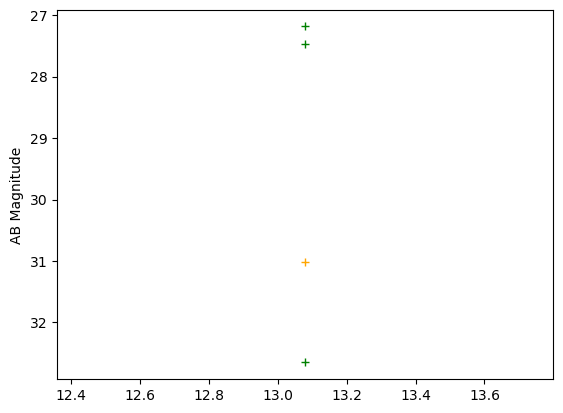

In [49]:
# flux to use is psfFlux
plt.plot(trans["radecMjdTai"]-60638, flux_to_mag_nJy(trans['g_psfFluxMean']), "+", color='c')
plt.plot(trans["radecMjdTai"]-60638, flux_to_mag_nJy(trans['r_psfFluxMean']), "+", color='g')
plt.plot(trans["radecMjdTai"]-60638, flux_to_mag_nJy(trans['i_psfFluxMean']), "+", color='orange')
plt.plot(trans["radecMjdTai"]-60638, flux_to_mag_nJy(trans['y_psfFluxMean']), "+", color='m')

plt.ylabel('AB Magnitude')
plt.gca().invert_yaxis()
#plt.ylim(30, 15)